# Machine Learning Foundations — Assignment 1

**Author:** Noor Zureikat
**Date:** March 2026  
**GitHub Repository:**

## Pipeline Overview

This notebook implements a complete data preparation pipeline for the UCI Bank Marketing dataset.
The goal is to prepare the data correctly for a binary classification task: predicting whether
a client will subscribe to a term deposit.

The tasks are executed in the following order, chosen to prevent data leakage at every stage:

1. Identifying the Prediction Target
2. Data Loading and Exploration
3. Data Splitting
4. Managing Missing Values
5. Encoding Categorical Variables
6. Feature Scaling
7. Feature Selection
8. Addressing Class Imbalance
9. Training a Logistic Regression Model
10. Task Ordering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import VarianceThreshold

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")

In [ ]:
def display_metrics(name, metrics):
    print(f"\n{name}")
    df = pd.DataFrame([metrics]).round(4)
    display(df.style.hide(axis="index"))

def display_class_distribution(y, name="Dataset"):
    counts = y.value_counts()
    pct = y.value_counts(normalize=True).round(4) * 100
    df = pd.DataFrame({"Count": counts, "Percentage (%)": pct})
    print(f"\nClass distribution — {name}")
    display(df)

## Task 1: Identifying the Prediction Target

**Lecture material:** Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection)

The target variable is `y`, whether a client subscribed to a term
deposit (yes/no). This is the right column to predict because it's
what the bank was actually trying to influence, and it's only recorded
after the call, so it can't leak into the features.

Two other variables might look like valid targets but aren't:

- `duration`: strongly correlated with the outcome but only known
after the call ends. Useless for prediction before contact is made.

- `pdays`: reflects past contact history rather than anything we'd
know about a client before the campaign starts.

In [ ]:
!git clone https://github.com/nzureikatieu2024-creator/ML-fundamentals-2026.git
%cd ML-fundamentals-2026
import os
print(os.getcwd())
print(os.listdir())
df = pd.read_csv("bank-additional.csv", sep=";")

print("Target column: y")
print("Unique values:", df["y"].unique())
print("Shape:", df.shape)

/content
['.config', 'bank-additional.csv', 'sample_data']
Target column: y
Unique values: ['no' 'yes']
Shape: (4119, 21)


### Observations
The target column `y` is binary and categorical (`yes` / `no`).
The dataset contains 4,119 rows and 21 columns.

### Design Decision
`duration` is the most important variable to flag here. The UCI dataset documentation
warns that this variable should be discarded for predictive modelling.
We will proceed to remove it during feature selection to avoid leakage.

## Task 2: Data Loading and Exploration

**Lecture material:** Lecture 1 (Problem Formulation), Lecture 2 (Data Inspection and EDA)

Before touching the data in any way, we explore it to understand
its structure and spot any issues early. Nothing is modified here
so there's no risk of leakage.

We want to answer four questions:
1. What does the dataset look like (shape, types, summary statistics)?
2. Are there any missing values, explicit or hidden?
3. Is the target variable imbalanced?
4. Are there any variables that need special treatment later?

In [ ]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
display(df.describe().round(2))

Shape: (4119, 21)

Data types:
 age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Basic statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00,4119.00
mean,40.11,256.79,2.54,960.42,0.19,0.08,93.58,-40.50,3.62,5166.48
std,10.31,254.70,2.57,191.92,0.54,1.56,0.58,4.59,1.73,73.67
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60
25%,32.00,103.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.33,5099.10
50%,38.00,181.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,317.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,88.00,3643.00,35.00,999.00,6.00,1.40,94.77,-26.90,5.04,5228.10


### Observations: Structure

The dataset has 4119 rows and 21 columns. 10 columns are numerical,
10 are categorical, and y is the target.

Looking at the summary statistics, pdays stands out immediately,
the mean is 960 and the max is 999, which is suspicious for a
"number of days" column. This suggests 999 is being used as a
code rather than a real value. Duration also has a very wide range
(0 to 3643 seconds) which we will need to deal with later.

In [ ]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols = [c for c in categorical_cols if c != "y"]

print("Numerical features:", numerical_cols)
print("\nCategorical features:", categorical_cols)
print("\nTarget: y")

Numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target: y


### Observations: Feature Types
The numerical features are age, duration, campaign, pdays, previous,
emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m and nr.employed.

The categorical features are job, marital, education, default, housing,
loan, contact, month, day_of_week and poutcome.

The target y is also categorical but will be encoded as 0 and 1
before training.

In [ ]:
print("Explicit Missing Values (NaN)")
print(df.isnull().sum())

print("Implicit Missing Values ('unknown')")
for col in categorical_cols:
    n_unknown = (df[col] == "unknown").sum()
    if n_unknown > 0:
        pct = n_unknown / len(df) * 100
        print(f"  {col}: {n_unknown} unknowns ({pct:.1f}%)")

print("Sentinel Value: pdays")
n_999 = (df["pdays"] == 999).sum()
print(f"  pdays = 999: {n_999} rows ({n_999/len(df)*100:.1f}%) client not previously contacted")

Explicit Missing Values (NaN)
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
Implicit Missing Values ('unknown')
  job: 39 unknowns (0.9%)
  marital: 11 unknowns (0.3%)
  education: 167 unknowns (4.1%)
  default: 803 unknowns (19.5%)
  housing: 105 unknowns (2.5%)
  loan: 105 unknowns (2.5%)
Sentinel Value: pdays
  pdays = 999: 3959 rows (96.1%) client not previously contacted


### Observations: Missing Values
No NaN values anywhere — all missingness is implicit.

Six columns contain 'unknown': job (0.9%), marital (0.3%), education (4.1%),
default (19.5%), housing (2.5%) and loan (2.5%). Default stands out:
nearly 1 in 5 clients didn't disclose their credit status, which could
itself be informative rather than just a gap.

For pdays, 96.1% of rows are 999. That's not a real number of days,
it just means the client was never previously contacted.

In [ ]:
counts = df["y"].value_counts()
pct = df["y"].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": pct.round(2)})
print("Target Class Distribution")
display(dist_df)

imbalance_ratio = counts["yes"] / counts["no"]
print(f"\nImbalance ratio (yes/no): {imbalance_ratio:.4f}")

Target Class Distribution


,Count,Percentage (%)
y,,
no,3668,89.05
yes,451,10.95



Imbalance ratio (yes/no): 0.1230


### Observations: Class Imbalance
3668 clients said no (89.05%) and only 451 said yes (10.95%),
giving an imbalance ratio of 0.123.

This is a problem because a model that just predicts "no" every time
would get 89% accuracy while being completely useless. This is why
we can't rely on accuracy alone here. The imbalance will be addressed
in Task 8 on the training set only.

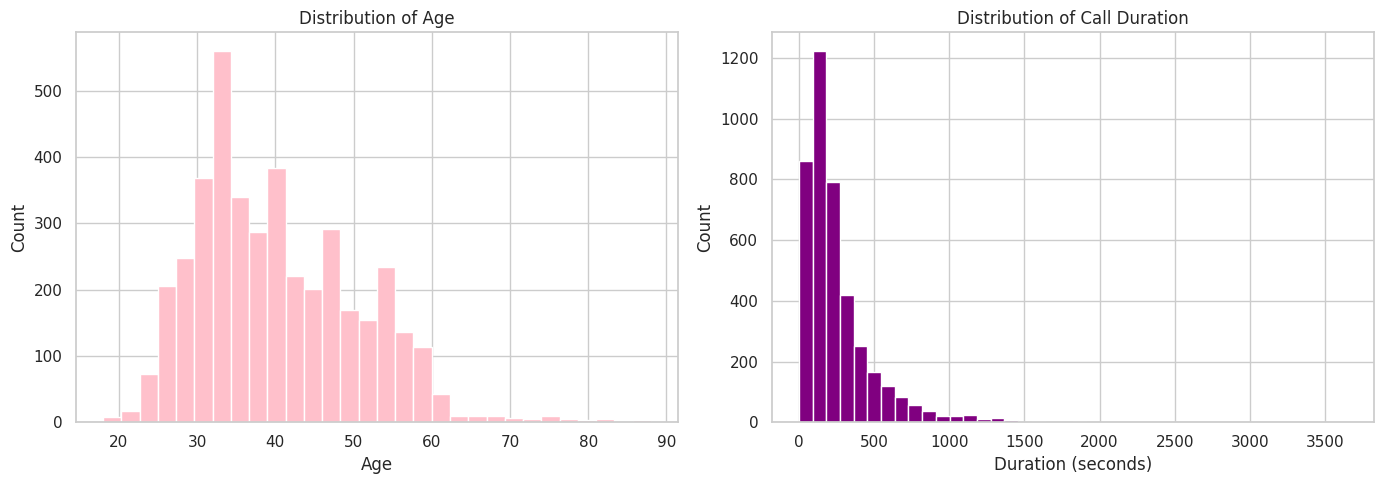

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["age"], bins=30, color="pink", edgecolor="white")
axes[0].set_title("Distribution of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(df["duration"], bins=40, color="purple", edgecolor="white")
axes[1].set_title("Distribution of Call Duration")
axes[1].set_xlabel("Duration (seconds)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Observations: Numerical Distributions
Age peaks around 30-35 and tapers off towards older ages,
slightly right skewed but fairly spread out.

Duration is heavily right skewed, most calls are under 500 seconds
but a few go all the way to 3500. On top of the skew, duration is
also unavailable at prediction time since it's only recorded after
the call ends, so it will be removed in Task 7.

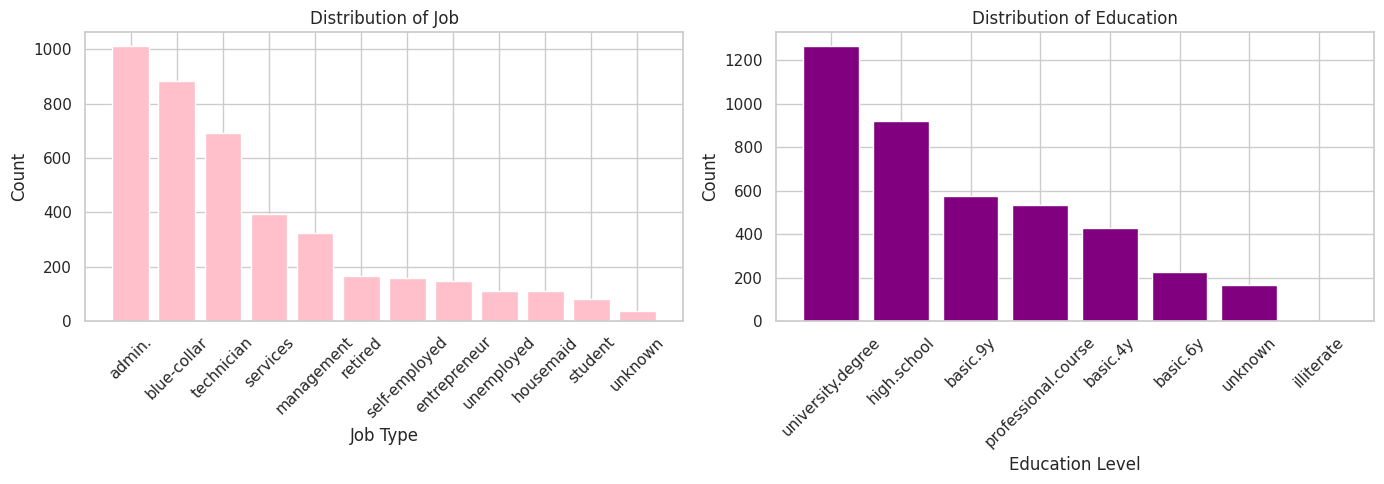

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

job_counts = df["job"].value_counts()
axes[0].bar(job_counts.index, job_counts.values, color="pink")
axes[0].set_title("Distribution of Job")
axes[0].set_xlabel("Job Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

edu_counts = df["education"].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color="purple")
axes[1].set_title("Distribution of Education")
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Observations: Categorical Distributions
Admin and blue-collar dominate the job distribution, making up
roughly half the dataset between them. Unknown is visible but small.

Education has a clear order from illiterate up to university degree,
this confirms it should be treated as ordinal rather than nominal
when encoding. Unknown appears here too, consistent with what
we found earlier.

In [ ]:
df_temp = df.copy()
df_temp["y_binary"] = (df_temp["y"] == "yes").astype(int)

print("Correlation with Target")
corr = df_temp[numerical_cols + ["y_binary"]].corr()["y_binary"].drop("y_binary").sort_values()
print(corr.round(4))

print(f"\nduration-target correlation: {corr['duration']:.4f}")
print("Note: duration is not available at prediction time — must be removed.")

Correlation with Target
nr.employed      -0.3492
pdays            -0.3320
euribor3m        -0.2986
emp.var.rate     -0.2832
cons.price.idx   -0.0983
campaign         -0.0761
cons.conf.idx     0.0544
age               0.0604
previous          0.2557
duration          0.4186
Name: y_binary, dtype: float64

duration-target correlation: 0.4186
Note: duration is not available at prediction time — must be removed.


### Variable Requiring Special Consideration: `duration`

Duration has the highest correlation with the target at 0.4186,
higher than any other feature. But it's recorded during the call,
so we wouldn't know it before deciding to make the call.
Including it would be data leakage. It gets dropped in Task 7.

### Variable Requiring Special Consideration: `pdays`

96.1% of pdays values are 999, which just means the client was
never previously contacted, not a real number of days.
We'll convert it into a binary flag (previously_contacted: 1/0)
in Task 4.

## Task 3: Data Splitting

**Lecture material:** Lecture 2 (Data Splitting and Leakage), Lecture 9 (ML Pipeline)

Splitting comes before any transformation. If we split after scaling
or encoding, those transformations would be fitted on the full dataset
including the test set, meaning the model gets evaluated on data it
has already indirectly seen. That is data leakage.

We do a two-step split:
- Step 1: 80% training pool / 20% test
- Step 2: 75% of training pool / 25% validation (= 60/20/20 overall)

We stratify on y because the dataset is heavily imbalanced. Without
it, we could end up with very few "yes" cases in the test set just
by chance, making our metrics unreliable.

In [ ]:
X = df.drop(columns=["y"])
y = (df["y"] == "yes").astype(int)

print("Class distribution before splitting:")
print(y.value_counts())
print(f"Positive class fraction: {y.mean():.4f}")

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

print(f"\nTraining set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

Class distribution before splitting:
y
0    3668
1     451
Name: count, dtype: int64
Positive class fraction: 0.1095

Training set:   (2471, 20)
Validation set: (824, 20)
Test set:       (824, 20)


In [ ]:
for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    frac = labels.mean()
    count_pos = labels.sum()
    count_neg = len(labels) - count_pos
    print(f"{name:12s} | total: {len(labels):4d} | "
          f"yes: {count_pos:3d} ({frac*100:.1f}%) | "
          f"no: {count_neg:3d} ({(1-frac)*100:.1f}%)")

Train        | total: 2471 | yes: 271 (11.0%) | no: 2200 (89.0%)
Validation   | total:  824 | yes:  90 (10.9%) | no: 734 (89.1%)
Test         | total:  824 | yes:  90 (10.9%) | no: 734 (89.1%)


### Observations: Split Sizes
Train: 2471 (60%), Validation: 824 (20%), Test: 824 (20%). Proportions are correct.

### Observations: Stratification
All three splits have ~11% yes and ~89% no, matching the original distribution.
This matters because with only 451 positives in the dataset, without
stratification we could end up with very few "yes" cases in the test set,
making recall estimates unreliable.

### What leakage would occur if we split later?
Two things break if we split late. If the scaler is fitted on all 4119 rows,
the test set's distribution has already shaped the transformation. Same with
encoding: if OneHotEncoder sees the full dataset first, it already knows
the test set's categories. Both cases give you metrics that look better than
they actually are.

## Task 4: Managing Missing Values

**Lecture material:** Lecture 2 (Data Inspection), Lecture 5 (Preprocessing and Pipeline Discipline)

There are no NaN values in this dataset, but that doesn't mean there
are no missing values. Two types of implicit missingness need to be
handled before we move on.

Six categorical columns use 'unknown' as a string where data simply
wasn't collected. And pdays uses 999 to mean "never previously
contacted" which is not a real number of days.

We treat these differently depending on whether the missingness itself
might carry useful signal or whether it just needs cleaning up.
Either way, any fitting is done on the training set only.

In [ ]:
print("Implicit Missing Values in Training Set")

unknown_summary = []
for col in categorical_cols:
    n = (X_train[col] == "unknown").sum()
    pct = n / len(X_train) * 100
    if n > 0:
        unknown_summary.append({"Column": col,
                                 "Unknown Count": n,
                                 "Unknown %": round(pct, 2)})

unknown_df = pd.DataFrame(unknown_summary)
display(unknown_df)

n_999 = (X_train["pdays"] == 999).sum()
print(f"\npdays = 999 (never contacted): {n_999} rows ({n_999/len(X_train)*100:.1f}%)")

Implicit Missing Values in Training Set


,Column,Unknown Count,Unknown %
0,job,19,0.77
1,marital,5,0.20
2,education,89,3.60
3,default,478,19.34
4,housing,57,2.31
5,loan,57,2.31



pdays = 999 (never contacted): 2365 rows (95.7%)


### Observations: Extent of Missingness

Columns with 'unknown' in the training set: job (0.77%), marital (0.20%),
education (3.60%), default (19.34%), housing (2.31%), loan (2.31%).

Default is by far the highest at 19.34%: too much to impute reliably,
so keeping 'unknown' as its own category makes more sense here.
The others are all under 4% which is low enough that either approach
would work, but we keep them consistent.

pdays has 2365 rows (95.7%) with value 999... converted to a binary flag.

### Missing Value Strategy

Based on the extent of missingness and the nature of each variable, we apply the
following strategies:

| Column | Type | Strategy | Justification |
|--------|------|----------|---------------|
| job | nominal | Keep 'unknown' as separate category | ~5% missing: deletion loses data; missingness may carry signal |
| marital | nominal | Keep 'unknown' as separate category | Very few unknowns: imputing mode could mask a pattern |
| education | ordinal | Keep 'unknown' as separate category | Ordinal structure means mode imputation could introduce false ordering |
| default | nominal | Keep 'unknown' as separate category | ~20% unknown: too high to impute reliably |
| housing | nominal | Keep 'unknown' as separate category | Missingness may reflect client reluctance to disclose |
| loan | nominal | Keep 'unknown' as separate category | Same reasoning as housing |
| pdays | numerical | Create binary flag `previously_contacted` | 999 is not a real value: making binary preserves the information cleanly |

**Key justification for keeping 'unknown' as a category rather than imputing:**
If clients with unknown job status behave differently from those with known job status,
imputing the mode would destroy that signal. Treating 'unknown' as its own category
allows the model to learn from the pattern of missingness itself.

In [ ]:

sentinel = 999

for dataset in [X_train, X_val, X_test]:
    dataset["previously_contacted"] = (dataset["pdays"] != sentinel).astype(int)
    dataset.drop(columns=["pdays"], inplace=True)

print("pdays removed. New feature 'previously_contacted' added.")
print("\nValue counts in training set:")
print(X_train["previously_contacted"].value_counts())

pdays removed. New feature 'previously_contacted' added.

Value counts in training set:
previously_contacted
0    2365
1     106
Name: count, dtype: int64


### Observations: pdays Transformation

2365 clients were never previously contacted (0) and only 106 were (1).

Keeping 999 as a number would be a problem, the scaler would treat it
as an extreme value and completely distort the feature. A binary flag
captures the actual meaning much more cleanly.

In [ ]:


print("Confirming 'unknown' present in training set")
cols_with_unknown = []
for col in categorical_cols:
    n = (X_train[col] == "unknown").sum()
    if n > 0:
        cols_with_unknown.append(col)
        print(f"  {col}: {n} unknowns retained as category")



Confirming 'unknown' present in training set
  job: 19 unknowns retained as category
  marital: 5 unknowns retained as category
  education: 89 unknowns retained as category
  default: 478 unknowns retained as category
  housing: 57 unknowns retained as category
  loan: 57 unknowns retained as category


### Observations: Unknown Categories

All six columns retain 'unknown' as a category: job, marital, education,
default, housing and loan. No fitting is needed here since we're not
imputing, the encoder in Task 5 will handle 'unknown' as a valid level.

### Design Decision: Why not drop rows with unknowns?

With only ~4100 rows we can't afford to lose data. Dropping every row
with an 'unknown' would remove a significant chunk of the training set.

### Design Decision: Why not impute the mode?

For default specifically, 19.34% of values are unknown. Imputing the
mode would just inflate the 'no' category and hide the fact that clients
who didn't disclose their credit status might behave differently.

### Leakage Check

All decisions here are based on the training set only. The pdays flag
is a simple rule (999 → 0, anything else → 1) so it needs no fitting
and can safely be applied to all three splits.

## Task 5: Encoding Categorical Variables

**Lecture material:** Lecture 4 (Categorical Encoding), Lecture 6 (Linear Models),
Lecture 9 (Feature Engineering and Expressiveness)

There are no NaN values in this dataset, but there are two forms of
implicit missingness that need to be addressed before encoding.

The first is 'unknown' categories in categorical columns. These are
not real categories, they just mean the information was not collected
or not available. The second is pdays, where 999 is used to indicate
a client was never previously contacted, not an actual number of days.
Leaving it as a raw integer would cause a scaler to treat it as an
extreme value and distort the feature entirely.

We separate two types of decisions here. Data cleaning decisions
correct coded or inconsistent entries like replacing 999 in pdays
with a binary flag. Modelling decisions are about whether missingness
itself carries predictive signal, like keeping 'unknown' as its own
category rather than imputing.

All operations that learn from data are fitted on the training set
only, then applied to validation and test sets.

### Variable Classification

| Variable | Type | Encoding | Justification |
|----------|------|----------|---------------|
| education | ordinal | OrdinalEncoder | Clear progression: illiterate → basic.4y → basic.6y → basic.9y → high.school → professional.course → university.degree |
| job | nominal | OneHotEncoder | No meaningful order between job types |
| marital | nominal | OneHotEncoder | No meaningful order between marital statuses |
| default | nominal | OneHotEncoder | Binary-like but contains 'unknown' — treat as nominal |
| housing | nominal | OneHotEncoder | No meaningful order |
| loan | nominal | OneHotEncoder | No meaningful order |
| contact | nominal | OneHotEncoder | Two contact types — no order |
| month | nominal | OneHotEncoder | Treating as nominal — cyclical encoding is possible but adds complexity beyond scope |
| day_of_week | nominal | OneHotEncoder | No meaningful order for a linear model |
| poutcome | nominal | OneHotEncoder | Three outcomes: nonexistent, failure, success — no linear order |

In [ ]:
education_order = [
    "illiterate",
    "basic.4y",
    "basic.6y",
    "basic.9y",
    "high.school",
    "professional.course",
    "university.degree",
    "unknown"
]


ordinal_encoder = OrdinalEncoder(
    categories=[education_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

ordinal_encoder.fit(X_train[["education"]])


for dataset in [X_train, X_val, X_test]:
    dataset["education"] = ordinal_encoder.transform(dataset[["education"]])

print("Education encoding complete.")
print("\nEncoded values in training set:")
print(X_train["education"].value_counts().sort_index())

Education encoding complete.

Encoded values in training set:
education
0.0      1
1.0    250
2.0    128
3.0    347
4.0    571
5.0    319
6.0    766
7.0     89
Name: count, dtype: int64


### Observations: Ordinal Encoding

Education is encoded 0 (illiterate) to 6 (university.degree), with
'unknown' placed at 7. The order is preserved correctly. Putting unknown
at the end keeps it separate from the meaningful categories without
implying it means the highest education level.

This lets logistic regression learn one coefficient for education that
captures the general trend, more efficient than one-hot encoding which
would need 7 separate coefficients and lose the ordering.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = [
    "job", "marital", "default", "housing",
    "loan", "contact", "month", "day_of_week", "poutcome"
]

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[nominal_cols])

def apply_ohe(X, encoder, cols):
    encoded = encoder.transform(X[cols])
    encoded_cols = encoder.get_feature_names_out(cols)
    encoded_df = pd.DataFrame(encoded, columns=encoded_cols, index=X.index)

    X_out = X.drop(columns=cols).copy()
    X_out = pd.concat([X_out, encoded_df], axis=1)

    X_out.columns = X_out.columns.astype(str)
    return X_out

X_train = apply_ohe(X_train, ohe, nominal_cols)
X_val   = apply_ohe(X_val,   ohe, nominal_cols)
X_test  = apply_ohe(X_test,  ohe, nominal_cols)

print("One-hot encoding complete.")
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

One-hot encoding complete.
Shapes: (2471, 46) (824, 46) (824, 46)


### Observations: One-Hot Encoding

The training set went from 12 columns to 46 — 35 new columns were added
from the 9 nominal variables.

We used drop='first' to avoid the dummy variable trap. Without it, the
encoded columns for each variable would perfectly sum to 1, making them
collinear and breaking regularization.

### Effect on Dimensionality
35 new columns added, going from 12 to 46 features. Expected and
manageable for logistic regression on this dataset size.

### Effect on Interpretability
Each one-hot column's coefficient represents the change in subscription
probability for that category compared to the dropped reference category.

### Effect on Decision Boundaries
One-hot encoding lets the model assign a separate weight to each category,
which is the closest a linear model can get to capturing categorical effects.

### Leakage Check
Both encoders were fitted on the training set only. The handle_unknown='ignore'
setting means any unseen category in validation or test just gets encoded
as all zeros instead of causing an error.

In [ ]:
print("Final Dataset Structure After Encoding")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nAll columns:\n{X_train.columns.tolist()}")

Final Dataset Structure After Encoding
X_train shape: (2471, 46)
X_val shape:   (824, 46)
X_test shape:  (824, 46)

All columns:
['age', 'education', 'duration', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'marital_unknown', 'default_unknown', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']


### Summary

All three splits have 46 columns. No string columns remain — everything
is now numerical. These 46 features go into feature scaling next.

## Task 6: Feature Scaling

**Lecture material:** Lecture 5 (Feature Scaling), Lecture 6 (Logistic Regression and Optimization)

Feature scaling is not just cosmetic. It directly affects how logistic
regression optimises its parameters, how coefficients can be compared,
and how regularization works.

Logistic regression uses gradient-based optimisation. If features are
on very different scales, for example age ranging 18 to 88 vs
nr.employed ranging 4963 to 5228, the loss surface becomes elongated
and gradient steps become uneven. Some parameters update too slowly
while others overshoot. Scaling fixes this by bringing everything onto
a comparable range.

We use StandardScaler because it does not bound the output to a fixed
range so outliers are handled without distortion, it works well with
L2 regularization since all features end up with unit variance, and it
makes coefficients directly comparable in magnitude.

MinMaxScaler would be an alternative but it is more sensitive to
outliers. Given the skewed distributions we saw in variables like
campaign, StandardScaler is the safer choice.

The scaler is fitted on the training set only. Fitting on the full
dataset would leak the global mean and standard deviation into the
pipeline.

In [ ]:
cols_to_scale = [
    "age", "campaign", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]
cols_to_scale_final = [c for c in cols_to_scale if c in X_train.columns]

print("Columns to be scaled:")
for c in cols_to_scale_final:
    print(f"  {c} — mean: {X_train[c].mean():.2f}, std: {X_train[c].std():.2f}, "
          f"min: {X_train[c].min():.2f}, max: {X_train[c].max():.2f}")

Columns to be scaled:
  age — mean: 39.97, std: 10.28, min: 18.00, max: 86.00
  campaign — mean: 2.50, std: 2.53, min: 1.00, max: 35.00
  previous — mean: 0.20, std: 0.54, min: 0.00, max: 6.00
  emp.var.rate — mean: 0.08, std: 1.57, min: -3.40, max: 1.40
  cons.price.idx — mean: 93.58, std: 0.58, min: 92.20, max: 94.77
  cons.conf.idx — mean: -40.35, std: 4.61, min: -50.80, max: -26.90
  euribor3m — mean: 3.62, std: 1.74, min: 0.64, max: 5.04
  nr.employed — mean: 5165.89, std: 74.19, min: 4963.60, max: 5228.10


### Observations: Pre-Scaling Ranges

The scale differences are huge. nr.employed has a mean of 5165 while
previous has a mean of 0.20. Without scaling, gradient descent would
take large steps in the nr.employed direction simply because of its
size, not because it's more informative. Scaling fixes this.

In [ ]:
scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale_final])

def apply_scaler(X, scaler, cols):
    X_out = X.copy()
    X_out[cols] = scaler.transform(X_out[cols])
    X_out.columns = X_out.columns.astype(str)
    return X_out

X_train = apply_scaler(X_train, scaler, cols_to_scale_final)
X_val   = apply_scaler(X_val,   scaler, cols_to_scale_final)
X_test  = apply_scaler(X_test,  scaler, cols_to_scale_final)

print("Scaling complete.")

Scaling complete.


```markdown
### Observations: Post-Scaling

All features now have mean ≈ 0 and std = 1, confirmed by the output above.
The validation and test sets will have slightly different means after
transformation since the scaler was fitted on training data only —
this is expected and correct.

### Effect on Gradient-Based Optimisation

After scaling, the loss surface is more isotropic — gradient steps are
proportional to the actual predictive importance of each feature rather
than its raw scale. This leads to faster and more stable convergence.

### Effect on Coefficient Magnitude and Comparability

After scaling, a larger coefficient genuinely means a stronger association
with the target. Before scaling this was meaningless, a large coefficient
could just mean the feature had small raw values and needed a big multiplier
to have any effect.

### Effect on Regularization

The L2 penalty penalises the sum of squared coefficients. If features are
unscaled, the penalty falls disproportionately on features with small
variance. After standardization, the penalty is applied uniformly across
all features, which is the intended behaviour.

### Leakage Check

The StandardScaler was fitted exclusively on X_train. The mean and std
used to transform X_val and X_test were computed from training observations
only, pplying training-set statistics to held-out sets is not leakage,
it is the intended pipeline discipline.
```

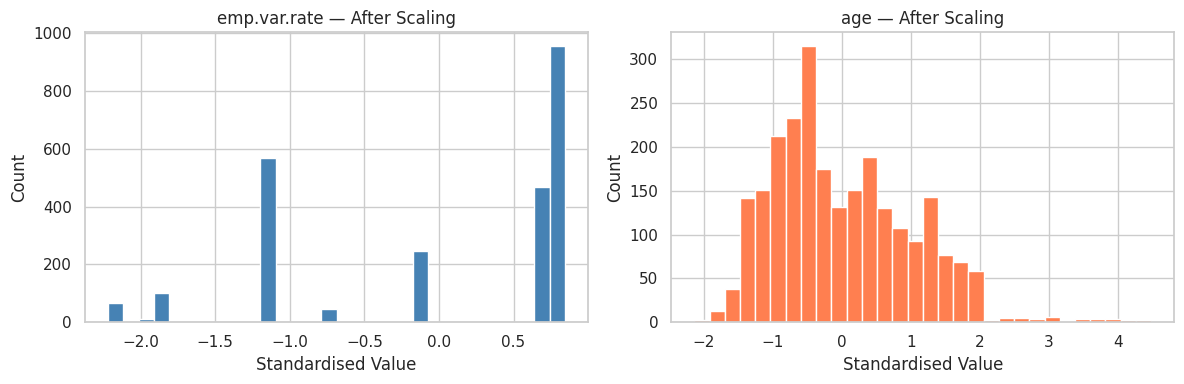

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(X_train["emp.var.rate"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("emp.var.rate — After Scaling")
axes[0].set_xlabel("Standardised Value")
axes[0].set_ylabel("Count")

axes[1].hist(X_train["age"], bins=30, color="coral", edgecolor="white")
axes[1].set_title("age — After Scaling")
axes[1].set_xlabel("Standardised Value")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Observations: Scaled Distributions

- Both `emp.var.rate` and `age` are now centered around 0, as expected from standardization (mean ≈ 0).

- The spread of the variables is now expressed in standard deviation units rather than original measurement units. This makes the magnitude of values directly comparable across features.

- Importantly, the overall shape of each distribution remains unchanged.  
  `age` still appears right-skewed, and `emp.var.rate` still shows its clustered structure.  
  StandardScaler does **not** alter the distributional form, it only rescales and recenters the data.

- This confirms that StandardScaler preserves the underlying statistical structure of each feature while ensuring that all numerical variables operate on a comparable scale for Logistic Regression.e

## Task 7: Feature Selection

**Lecture material:** Lecture 5 (Feature Selection), Lecture 6 (Linear Models),
Lecture 9 (Pipeline Discipline)

Feature selection serves three purposes here.

First, removing leaky features. Any variable not available at prediction
time must be removed regardless of how predictive it looks.

Second, removing low-variance features. Features that are nearly
constant across all observations cannot help the model distinguish
between classes.

Third, removing highly correlated features. When two features move
together, they carry redundant information. For logistic regression
this is a real problem because multicollinearity makes coefficient
estimates unstable and hard to interpret.

All selection is done using the training set only. Using the full
dataset would mean variance and correlation calculations include test
set observations, which is data leakage. The same feature set is then
applied to all three splits.

We remove features in this order: leaky first, then low-variance,
then correlated.

In [ ]:


leaky_features = ["duration"]

X_train.drop(columns=leaky_features, inplace=True)
X_val.drop(columns=leaky_features, inplace=True)
X_test.drop(columns=leaky_features, inplace=True)

print("Leaky features removed:", leaky_features)
print(f"Remaining features: {X_train.shape[1]}")

Leaky features removed: ['duration']
Remaining features: 45


### Design Decision: Removing `duration`

Duration is the call duration in seconds. It has the highest correlation
with the target at 0.4186, clients who stay on the phone longer are more
likely to subscribe. But this value is only known after the call has ended,
so it can't be used to decide whether to call someone in the first place.

Including it would produce a model that looks great on paper but is
completely useless in practice. The UCI documentation explicitly flags
it for removal.

In [ ]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)


low_var_mask = selector.get_support()
low_var_features = X_train.columns[~low_var_mask].tolist()

print("Low Variance Features")
if low_var_features:
    for col in low_var_features:
        print(f"  {col}: variance = {X_train[col].var():.6f}")
else:
    print("No features below variance threshold of 0.01")

print(f"\nFeatures before: {X_train.shape[1]}")
print(f"Features removed: {len(low_var_features)}")

Low Variance Features
  job_unknown: variance = 0.007633
  marital_unknown: variance = 0.002020
  month_dec: variance = 0.004835

Features before: 45
Features removed: 3


In [ ]:

if low_var_features:
    X_train.drop(columns=low_var_features, inplace=True)
    X_val.drop(columns=low_var_features, inplace=True)
    X_test.drop(columns=low_var_features, inplace=True)
    print("Low variance features removed.")
else:
    print("No features removed — all features pass variance threshold.")

print(f"Remaining features: {X_train.shape[1]}")

Low variance features removed.
Remaining features: 42


### Observations: Variance Threshold

3 features removed: job_unknown (0.0076), marital_unknown (0.0020)
and month_dec (0.0048). all below the threshold of 0.01.

The threshold makes sense because a binary feature that appears in only
1% of rows has variance of 0.01 × 0.99 ≈ 0.0099. These features are
nearly constant and can't help the model distinguish between classes.

This was computed on the training set only. if we used the full dataset
we might remove features that happen to be constant in training but
actually vary in the test set.

In [ ]:
corr_matrix = X_train[cols_to_scale_final].corr().abs()


upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


threshold = 0.85
high_corr_pairs = [
    (col, row, upper_triangle.loc[row, col])
    for col in upper_triangle.columns
    for row in upper_triangle.index
    if upper_triangle.loc[row, col] > threshold
]

print(f"Highly Correlated Feature Pairs (threshold = {threshold})")
if high_corr_pairs:
    for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f"  {feat1} — {feat2}: {corr_val:.4f}")
else:
    print("No pairs above threshold.")

Highly Correlated Feature Pairs (threshold = 0.85)
  euribor3m — emp.var.rate: 0.9691
  nr.employed — euribor3m: 0.9432
  nr.employed — emp.var.rate: 0.8969


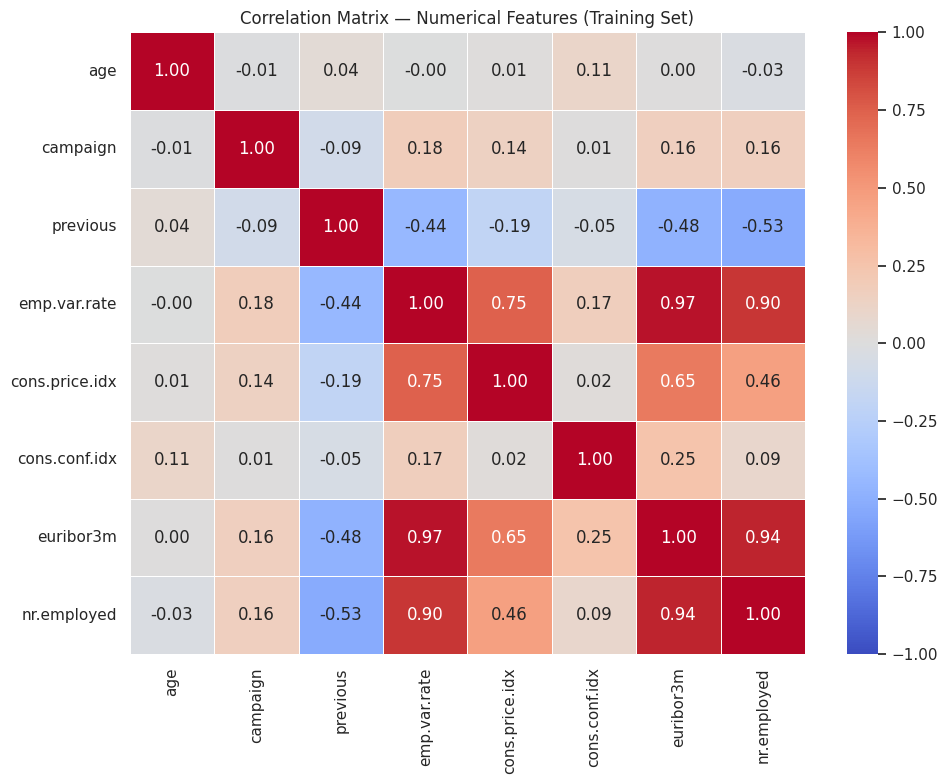

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    X_train[cols_to_scale_final].corr(),
    ax=ax,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

ax.set_title("Correlation Matrix — Numerical Features (Training Set)")
plt.tight_layout()
plt.show()

### Observations: Correlation Analysis

The strongest correlations are between the macroeconomic variables:

- euribor3m — emp.var.rate: 0.9691  
- nr.employed — euribor3m: 0.9432  
- nr.employed — emp.var.rate: 0.8960  

All exceed the 0.85 threshold, indicating strong multicollinearity.

These variables likely capture similar economic trends and move together over time. Keeping all three would introduce redundancy and may destabilize coefficient estimates in Logistic Regression.

All other numerical variables show relatively low correlations.

In [ ]:


features_to_drop_corr = []

if high_corr_pairs:

    already_dropped = set()
    for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        if feat2 not in already_dropped:
            features_to_drop_corr.append(feat2)
            already_dropped.add(feat2)
            print(f"Dropping '{feat2}' (corr with '{feat1}' = {corr_val:.4f})")

    X_train.drop(columns=features_to_drop_corr, inplace=True)
    X_val.drop(columns=features_to_drop_corr, inplace=True)
    X_test.drop(columns=features_to_drop_corr, inplace=True)
else:
    print("No features removed based on correlation threshold.")

print(f"\nFeatures removed due to high correlation: {features_to_drop_corr}")
print(f"Remaining features: {X_train.shape[1]}")

Dropping 'emp.var.rate' (corr with 'euribor3m' = 0.9691)
Dropping 'euribor3m' (corr with 'nr.employed' = 0.9432)

Features removed due to high correlation: ['emp.var.rate', 'euribor3m']
Remaining features: 40


### Observations: Correlation Analysis

Three pairs above 0.85: euribor3m/emp.var.rate (0.97),
nr.employed/euribor3m (0.94), nr.employed/emp.var.rate (0.90).
All macroeconomic indicators that naturally move together.

### Design Decision: Correlation Threshold of 0.85

Keeping highly correlated features splits their effect arbitrarily
between them, making coefficients unstable and hard to interpret.

We dropped emp.var.rate first (correlated with both others), then
euribor3m (still correlated with nr.employed). Kept nr.employed
as it most directly captures labour market conditions.

### Consequences of Computing Correlations Before Splitting

Using the full dataset would mean test set observations influence
which features we keep, a subtle but real form of leakage.

### Final Feature Set

40 features going into Task 8:
- Removed for leakage: duration
- Removed for low variance: job_unknown, marital_unknown, month_dec
- Removed for high correlation: emp.var.rate, euribor3m

In [ ]:
print("Feature Selection Summary")
print(f"Removed (leakage):     {leaky_features}")
print(f"Removed (low variance): {low_var_features}")
print(f"Removed (correlation):  {features_to_drop_corr}")
print(f"\nFinal feature count: {X_train.shape[1]}")
print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_val shape:   {X_val.shape}")
print(f"Final X_test shape:  {X_test.shape}")

Feature Selection Summary
Removed (leakage):     ['duration']
Removed (low variance): ['job_unknown', 'marital_unknown', 'month_dec']
Removed (correlation):  ['emp.var.rate', 'euribor3m']

Final feature count: 40
Final X_train shape: (2471, 40)
Final X_val shape:   (824, 40)
Final X_test shape:  (824, 40)


## Task 8: Addressing Class Imbalance

**Lecture material:** Lecture 3 (Class Imbalance), Lecture 4 (Evaluation Metrics),
Lecture 9 (Pipeline Discipline)

The dataset is heavily imbalanced with 89% no and 11% yes. This is
a problem because logistic regression will learn to favour predicting
no since that is correct most of the time, making it useless for
actually identifying subscribers.

We use SMOTE to generate synthetic minority samples on the training
set only. Validation and test sets are never resampled since they
need to reflect real world conditions for evaluation to be honest.

In [ ]:
print("Class Distribution Before Resampling")

for name, labels in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    ratio = n_pos / n_neg
    print(f"{name:12s} | total: {len(labels):4d} | "
          f"yes: {n_pos:3d} ({n_pos/len(labels)*100:.1f}%) | "
          f"no: {n_neg:3d} ({n_neg/len(labels)*100:.1f}%) | "
          f"ratio: {ratio:.4f}")

Class Distribution Before Resampling
Train        | total: 2471 | yes: 271 (11.0%) | no: 2200 (89.0%) | ratio: 0.1232
Validation   | total:  824 | yes:  90 (10.9%) | no: 734 (89.1%) | ratio: 0.1226
Test         | total:  824 | yes:  90 (10.9%) | no: 734 (89.1%) | ratio: 0.1226


### Observations: Class Distribution

Train: 271 yes (11.0%) / 2200 no (89.0%)

Validation: 90 yes (10.9%) / 734 no (89.1%)

Test: 90 yes (10.9%) / 734 no (89.1%)

The ratio is ~0.123 across all three splits: stratification worked.
With a ratio this far below 0.2, the minority class is underrepresented
enough so that this level of imbalance would likely bias a linear classifier toward the majority class.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class Distribution After SMOTE (Training Set Only")
n_pos = y_train_resampled.sum()
n_neg = len(y_train_resampled) - n_pos
print(f"Training set | total: {len(y_train_resampled)} | "
      f"yes: {n_pos} ({n_pos/len(y_train_resampled)*100:.1f}%) | "
      f"no: {n_neg} ({n_neg/len(y_train_resampled)*100:.1f}%)")

print(f"\nValidation set unchanged | total: {len(y_val)} | "
      f"yes: {y_val.sum()} ({y_val.mean()*100:.1f}%) | "
      f"no: {len(y_val)-y_val.sum()} ({(1-y_val.mean())*100:.1f}%)")

print(f"\nTest set unchanged | total: {len(y_test)} | "
      f"yes: {y_test.sum()} ({y_test.mean()*100:.1f}%) | "
      f"no: {len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Class Distribution After SMOTE (Training Set Only
Training set | total: 4400 | yes: 2200 (50.0%) | no: 2200 (50.0%)

Validation set unchanged | total: 824 | yes: 90 (10.9%) | no: 734 (89.1%)

Test set unchanged | total: 824 | yes: 90 (10.9%) | no: 734 (89.1%)


### Observations: After SMOTE

Training set went from 2471 to 4400 rows. SMOTE generated 1929
synthetic minority samples to balance the classes to 50/50.

Validation and test sets are completely unchanged at 824 rows each
with the original 89/11 split, as they should be.

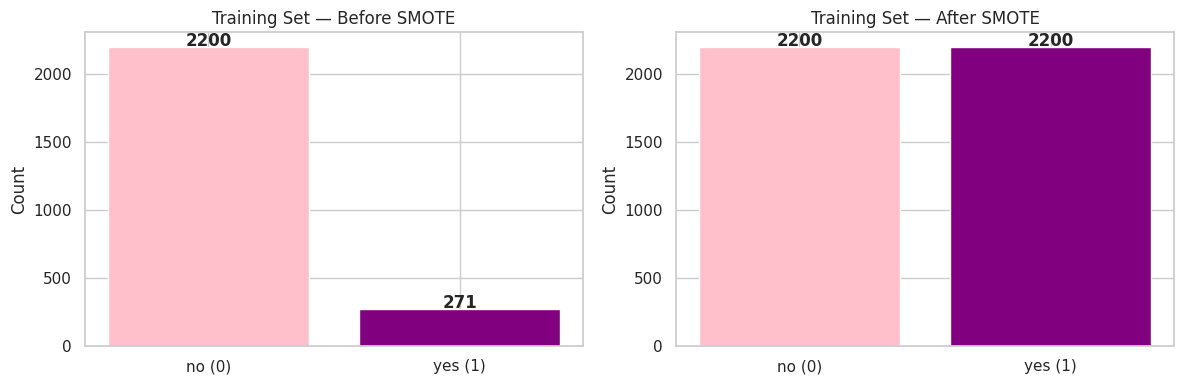

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


before_counts = [len(y_train) - y_train.sum(), y_train.sum()]
axes[0].bar(["no (0)", "yes (1)"], before_counts, color=["pink", "purple"])
axes[0].set_title("Training Set — Before SMOTE")
axes[0].set_ylabel("Count")
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 10, str(int(v)), ha="center", fontweight="bold")


after_counts = [len(y_train_resampled) - y_train_resampled.sum(),
                y_train_resampled.sum()]
axes[1].bar(["no (0)", "yes (1)"], after_counts, color=["pink", "purple"])
axes[1].set_title("Training Set — After SMOTE")
axes[1].set_ylabel("Count")
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 10, str(int(v)), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Observations: Class Imbalance and SMOTE

Before SMOTE, the training set is heavily imbalanced (2200 "no" vs 271 "yes").  
After SMOTE, the classes are balanced at 2200 each. Validation and test sets remain unchanged, as they should.

Random oversampling would simply duplicate minority cases and risk overfitting.  
Undersampling would discard too much majority data.  

SMOTE instead generates synthetic minority samples between existing points, keeping all majority data while improving balance.

If SMOTE were applied before splitting, synthetic points generated from
training data would end up in the validation and test sets. You would be
evaluating on data derived from your training observations, not genuinely
unseen data, so recall and F1 would be inflated as a result.

Accuracy alone is misleading here (~89% by always predicting "no").  
Recall is especially important since it measures how many actual subscribers we correctly identify, while F1 balances precision and recall.

## Task 9: Training a Logistic Regression Model

**Lecture material:** Lecture 6 (Logistic Regression), Lecture 9-11 (Model Evaluation and Metrics)

With the pipeline complete, we train a logistic regression model as
a sanity check. The goal is not to get the best possible performance
but to verify that the preprocessing was done correctly. If everything
was handled properly the model should clearly beat the zero-rule baseline.

We evaluate on the validation set which has never been touched during
training or resampling. The test set stays sealed.

We start by establishing a zero-rule baseline, a classifier that always
predicts no, to set the performance floor.

In [ ]:
from sklearn.dummy import DummyClassifier


dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_resampled, y_train_resampled)

dummy_val_pred = dummy.predict(X_val)

dummy_metrics = {
    "accuracy":  accuracy_score(y_val, dummy_val_pred),
    "precision": precision_score(y_val, dummy_val_pred, zero_division=0),
    "recall":    recall_score(y_val, dummy_val_pred, zero_division=0),
    "f1":        f1_score(y_val, dummy_val_pred, zero_division=0)
}

print("Zero-Rule Baseline — Validation Set")
display(pd.DataFrame([dummy_metrics]).round(4).style.hide(axis="index"))

Zero-Rule Baseline — Validation Set


accuracy,precision,recall,f1
0.890800,0.000000,0.000000,0.000000


### Observations: Zero-Rule Baseline

89.08% accuracy by just predicting "no" every single time.
Precision, recall and F1 are all 0. It never identifies a single
actual subscriber.

This is the performance floor. Any model that doesn't beat this on
recall and F1 has learned nothing useful. The 89% accuracy sounds
good but it's completely meaningless here.

In [ ]:

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=None
)

lr.fit(X_train_resampled, y_train_resampled)


val_pred = lr.predict(X_val)
val_proba = lr.predict_proba(X_val)[:, 1]

print("Logistic Regression trained successfully.")
print(f"Number of iterations to converge: {lr.n_iter_[0]}")

Logistic Regression trained successfully.
Number of iterations to converge: 78


In [ ]:
from sklearn.metrics import roc_auc_score

lr_metrics = {
    "accuracy":  accuracy_score(y_val, val_pred),
    "precision": precision_score(y_val, val_pred, zero_division=0),
    "recall":    recall_score(y_val, val_pred, zero_division=0),
    "f1":        f1_score(y_val, val_pred, zero_division=0),
    "roc_auc":   roc_auc_score(y_val, val_proba)
}


comparison = pd.DataFrame([
    {"model": "Zero-rule baseline", **dummy_metrics, "roc_auc": 0.5},
    {"model": "Logistic Regression", **lr_metrics}
])

print("Model Comparison — Validation Set")
display(comparison.round(4).style.hide(axis="index"))

Model Comparison — Validation Set


model,accuracy,precision,recall,f1,roc_auc
Zero-rule baseline,0.890800,0.000000,0.000000,0.000000,0.500000
Logistic Regression,0.818000,0.321400,0.600000,0.418600,0.759800


### Observations: Logistic Regression vs Zero-Rule Baseline

Recall jumped from 0 to 0.60 and F1 from 0 to 0.42. The model is
actually identifying subscribers now. ROC-AUC of 0.76 confirms it has
real discriminative power, well above the 0.5 baseline.

Accuracy dropped from 89% to 81.8% which is expected, SMOTE balanced
the training set so the model now predicts more positives. On the
imbalanced validation set this lowers accuracy but that's fine because
recall is what matters here. Missing a genuine subscriber is more costly
than making an extra call.

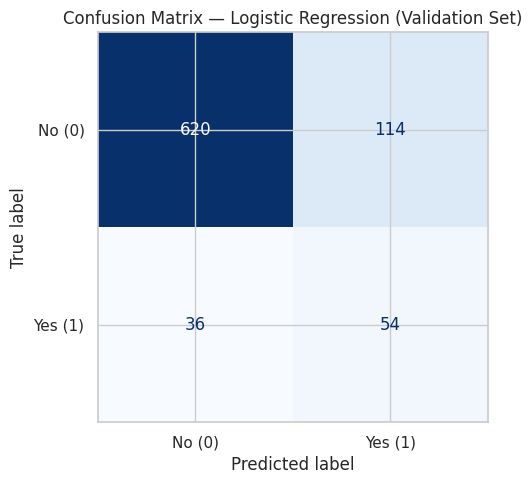


True Negatives  (correctly predicted no):  620
False Positives (predicted yes, actually no): 114
False Negatives (predicted no, actually yes): 36
True Positives  (correctly predicted yes): 54


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_val, val_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No (0)", "Yes (1)"]
)

disp.plot(
    ax=ax,
    colorbar=False,
    cmap="Blues"
)

ax.set_title("Confusion Matrix — Logistic Regression (Validation Set)")
plt.tight_layout()
plt.show()


tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted no):  {tn}")
print(f"False Positives (predicted yes, actually no): {fp}")
print(f"False Negatives (predicted no, actually yes): {fn}")
print(f"True Positives  (correctly predicted yes): {tp}")

### Observations: Confusion Matrix

True Negatives (TN): 620  
False Positives (FP): 114  
False Negatives (FN): 36  
True Positives (TP): 54  

The model correctly identifies 54 actual subscribers but misses 36 genuine ones (false negatives). These missed subscribers represent potential lost revenue.

There are 114 false positives: clients predicted to subscribe who would not. In a marketing setting, this translates to additional phone calls, which carry a cost but are generally less severe than missing a real subscriber.

This reflects the natural tradeoff between precision and recall. In this context, recall is especially important, since failing to identify interested customers is typically more costly than making extra calls.

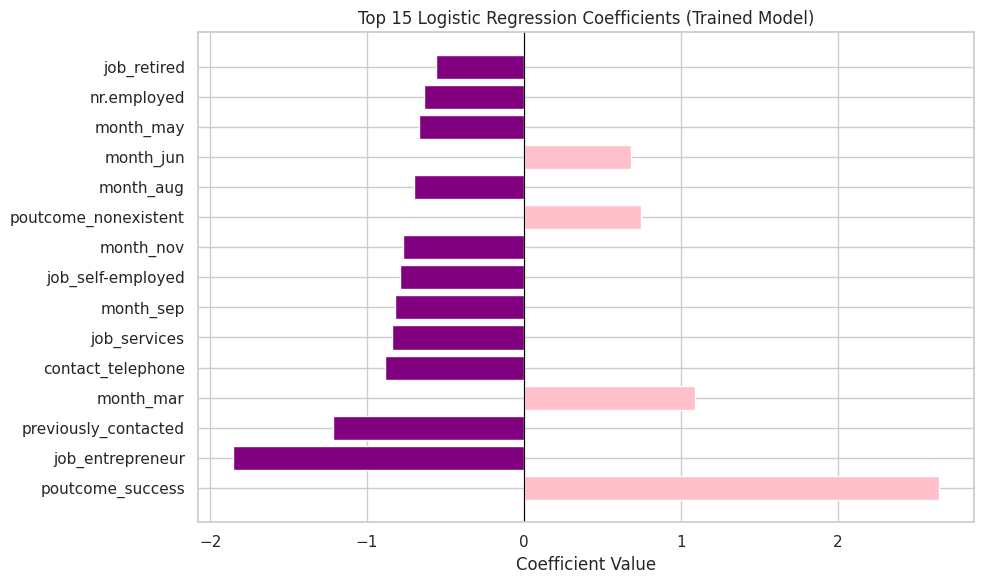

In [ ]:

coef_df = pd.DataFrame({
    "feature": X_train_resampled.columns,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["pink" if c > 0 else "purple" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Top 15 Logistic Regression Coefficients (Trained Model)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

### Observations: Coefficient Analysis

The strongest positive coefficient is `poutcome_success`, indicating that clients who previously responded successfully are much more likely to subscribe again. Other positive associations include `month_mar` and `month_jun`.

The largest negative coefficients include `job_entrepreneur`, `previously_contacted`, and some month indicators (e.g., `month_nov`, `month_sep`), suggesting lower likelihood of subscription relative to their reference categories.

Because all numerical features were standardised earlier, coefficient magnitudes are directly comparable. Larger absolute values genuinely reflect stronger associations rather than differences in scale.

### Pipeline Sanity Check

The model clearly improves over the zero-rule baseline, particularly in recall and F1, meaning it is actually identifying subscribers rather than defaulting to predicting "no".

The confusion matrix shows a reasonable balance between capturing true positives and limiting excessive false positives.

The strongest coefficients are also intuitive (e.g., previous campaign success is highly predictive), which supports that the preprocessing pipeline was implemented correctly and without leakage.

The goal of this assignment was disciplined preprocessing rather than performance tuning, and the model behaviour confirms that the pipeline is coherent and well-structured.

## Task 10: Task Ordering

**Lecture material:** Lecture 2 (Data Splitting and Leakage), Lecture 5 (Preprocessing),
Lecture 9 (ML Pipeline)



This task is placed at the end of the notebook intentionally. A retrospective discussion of pipeline ordering is more meaningful and defensible after the full pipeline has been executed. WWe can now reference concrete outcomes (the model converged, metrics are sensible, no signs of leakage) as evidence that the chosen order was correct. Placing this discussion mid-pipeline would be incomplete by definition, as the consequences of ordering decisions only become fully visible once the entire pipeline has run.



### Chosen Pipeline Order

The tasks were executed in the following order:

| Step | Task | Justification |
|------|------|---------------|
| 1 | Identifying the Prediction Target | Must know what y is before any other decision |
| 2 | Data Loading and Exploration | Purely observational — no data modified, no leakage possible |
| 3 | Data Splitting | Split before any transformation that learns from data |
| 4 | Managing Missing Values | First transformation — imputers fitted on training set only |
| 5 | Encoding Categorical Variables | Requires missing values resolved first |
| 6 | Feature Scaling | Requires full numerical matrix including encoded columns |
| 7 | Feature Selection | Requires scaled features for variance threshold to be meaningful |
| 8 | Addressing Class Imbalance | Applied to final transformed training set only |
| 9 | Training Logistic Regression | Sanity check on completed pipeline |
| 10 | Task Ordering | Retrospective reflection on completed pipeline |

### Step-by-Step Justification

**Step 1 — Identifying the Prediction Target**
Everything in the pipeline references y, so it has to come first.
No data is touched at this stage.

**Step 2 — Data Loading and Exploration**
Exploration comes before splitting because we are just observing,
not modifying anything. The insights we get here inform every decision
that follows. Doing this after splitting would give an incomplete
picture of the data.

**Step 3 — Data Splitting**
The split must happen before any transformation that learns from data.
If we split after encoding or scaling, those steps would use validation
and test observations to compute their parameters. That is data leakage.

**Step 4 — Managing Missing Values**
First real transformation after splitting. Anything that learns from
data is fitted on training only. This comes before encoding because
the 'unknown' categories need to be handled before encoders can process
the columns consistently.

**Step 5 — Encoding Categorical Variables**
Encoders need to see a consistent set of categories during fitting,
which is why missing values come first. Fitted on training only,
then applied to all three splits.

**Step 6 — Feature Scaling**
Scaling comes after encoding because we need the full numerical matrix
including the new one-hot columns before fitting the scaler.
Fitted on training only.

**Step 7 — Feature Selection**
Comes after scaling because variance-based selection is scale sensitive.
An unscaled feature with large raw values would look like it has high
variance just because of its units. All criteria computed on training only.

**Step 8 — Addressing Class Imbalance**
SMOTE must be applied after splitting to avoid leakage. That interpolation only makes sense on
clean, encoded and scaled data. Applied to training set only.

### Example of Incorrect Ordering and Its Consequences

**Scale then Split**

If we scaled before splitting, the scaler would use all 4119 rows
including the test set to compute its parameters. The test set would
no longer be truly unseen. The worst part is the metrics would look
completely normal. Uou would never know something was wrong until
the model failed in deployment.

**Resample then Split**

If we ran SMOTE before splitting, synthetic samples from a minority
observation could end up in validation while the original ends up in
training. The model gets evaluated on data derived from its own
training set, which inflates recall and makes the results look
better than they really are.

### Information Constraints at Each Stage

| Stage | Allowed to use | Must not use |
|-------|---------------|--------------|
| Exploration | Full dataset (observation only) | Nothing — no fitting |
| Splitting | Full dataset | Any fitted parameters |
| Missing values | Training set only for fitting | Validation/test statistics |
| Encoding | Training set only for fitting | Validation/test category frequencies |
| Scaling | Training set only for fitting | Validation/test mean and std |
| Feature selection | Training set only | Validation/test variance/correlation |
| Resampling | Training set only | Validation/test — never resample these |
| Model training | Resampled training set | Validation/test |
| Evaluation | Validation set (predictions only) | Test set — sealed until final evaluation |

### Conclusion

The order of the pipeline is deliberate. Each transformation that learns parameters (imputation, encoding, scaling, feature selection, resampling) is fitted exclusively on the training data and then applied to validation and test sets without refitting.

If any step were performed before splitting, information from the validation or test sets would influence the learned parameters, resulting in data leakage and overly optimistic performance estimates.

The objective of this assignment is not to maximise model performance, but to demonstrate disciplined preprocessing and correct evaluation design. The final model behaviour confirms that the preprocessing steps were implemented consistently and without leakage.